# 05f — Model F Training: Lap Time Simulation

Predicts **lap_time_ratio** (lap_time / best_quali_time) for autoregressive
race simulation. Positions derived by ranking cumulative predicted times.

| Feature Group | Count | Description |
|---|---|---|
| Static | 5 | Grid, quali pace, circuit type |
| Deterministic | 10 | Lap, tyre, pit state |
| Feedback | 6 | Rolling pace, gaps, position |
| Context | 1 | Caution flag |
| **Total** | **22** | |

CV: ExpandingWindowSplit (2019→2020, 2019-20→2021, ..., 2019-23→2024 test).

## 0. Setup

In [1]:
import os
from pathlib import Path

if not (Path.cwd() / "pyproject.toml").exists():
    # We're likely in notebooks/ — go up to repo root
    for p in [Path.cwd().parent, Path.cwd().parent.parent]:
        if (p / "pyproject.toml").exists():
            os.chdir(p)
            break

print(f"Working directory: {Path.cwd()}")

Working directory: /opt/f1-training


In [2]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

from f1_predictor.features.splits import ExpandingWindowSplit, LeaveOneSeasonOut
from f1_predictor.data.storage import (
    load_from_gcs_or_local,
    load_training_parquet,
    save_training_parquet,
    save_model_pickle as gcs_save_model_pickle,
    save_notebook,
    sync_training_from_gcs,
)
from f1_predictor.models.gpu import (
    detect_gpu_backend, get_lightgbm_device, get_torch_device, get_xgboost_device,
)

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

TRAINING_DIR = Path("data/training")
MODEL_DIR = Path("data/raw/model")
TRAINING_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# GPU detection (supports NVIDIA CUDA and AMD ROCm)
GPU_BACKEND, GPU_NAME = detect_gpu_backend()
TORCH_DEVICE = get_torch_device()
print(f"GPU backend: {GPU_BACKEND} ({GPU_NAME})")
print(f"PyTorch device: {TORCH_DEVICE}")

# Deep learning models (PyTorch — works on both CUDA and ROCm via HIP)
DL_AVAILABLE = False
try:
    from f1_predictor.models.architectures import GRU2Layer, FTTransformerWrapper, MLP3Layer
    DL_AVAILABLE = TORCH_DEVICE != "cpu"
    print(f"DL models available: {DL_AVAILABLE}")
except (ImportError, NameError):
    print("DL models not available (torch/rtdl not installed)")

GPU backend: cuda (NVIDIA L4)
PyTorch device: cpu
DL models not available (torch/rtdl not installed)


In [3]:
NAN_TOLERANT = {
    "XGBoost", "XGBoost_DART", "XGBoost_Linear",
    "LightGBM", "LightGBM_DART", "LightGBM_GOSS",
    "XGBoost_Conservative", "XGBoost_Deep",
    "LightGBM_Shallow", "LightGBM_Deep",
}

DL_SKIP_OPTUNA = {"GRU_2layer", "FT_Transformer", "MLP_3layer"}


def get_candidates():
    """Return dict of model_name -> model instance. GPU-accelerated where possible."""
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)

    candidates = {
        # XGBoost variants (GPU on CUDA, CPU on ROCm)
        "XGBoost": xgb.XGBRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "XGBoost_DART": xgb.XGBRegressor(
            n_estimators=300, booster="dart", n_jobs=-1,
            random_state=42, verbosity=0, **xgb_device),
        "XGBoost_Linear": xgb.XGBRegressor(
            n_estimators=300, booster="gblinear", n_jobs=-1,
            random_state=42, verbosity=0, **xgb_device),
        # LightGBM variants (GPU via OpenCL on both CUDA and ROCm)
        "LightGBM": lgb.LGBMRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "LightGBM_DART": lgb.LGBMRegressor(
            n_estimators=300, boosting_type="dart", n_jobs=-1,
            random_state=42, verbose=-1, **lgb_device),
        "LightGBM_GOSS": lgb.LGBMRegressor(
            n_estimators=300, boosting_type="goss", n_jobs=-1,
            random_state=42, verbose=-1, **lgb_device),
        # Extra tree-based variants
        "XGBoost_Conservative": xgb.XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "LightGBM_Shallow": lgb.LGBMRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "XGBoost_Deep": xgb.XGBRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.1,
            n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "LightGBM_Deep": lgb.LGBMRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.1,
            n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
    }

    # Deep learning candidates (PyTorch — works on both CUDA and ROCm via HIP)
    if DL_AVAILABLE:
        n_feat = len(FEATURE_COLS)
        candidates["GRU_2layer"] = GRU2Layer(input_dim=n_feat)
        candidates["FT_Transformer"] = FTTransformerWrapper(n_features=n_feat)

    print(f"Candidates ({len(candidates)}): {list(candidates.keys())}")
    return candidates


def get_candidates_c():
    """Return dict of candidates for Model C (race-level, includes MLP)."""
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)

    candidates = {
        "XGBoost": xgb.XGBRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "XGBoost_DART": xgb.XGBRegressor(
            n_estimators=300, booster="dart", n_jobs=-1,
            random_state=42, verbosity=0, **xgb_device),
        "XGBoost_Linear": xgb.XGBRegressor(
            n_estimators=300, booster="gblinear", n_jobs=-1,
            random_state=42, verbosity=0, **xgb_device),
        "LightGBM": lgb.LGBMRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "LightGBM_DART": lgb.LGBMRegressor(
            n_estimators=300, boosting_type="dart", n_jobs=-1,
            random_state=42, verbose=-1, **lgb_device),
        "LightGBM_GOSS": lgb.LGBMRegressor(
            n_estimators=300, boosting_type="goss", n_jobs=-1,
            random_state=42, verbose=-1, **lgb_device),
        "XGBoost_Conservative": xgb.XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "LightGBM_Shallow": lgb.LGBMRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "XGBoost_Deep": xgb.XGBRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.1,
            n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "LightGBM_Deep": lgb.LGBMRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.1,
            n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
    }

    if DL_AVAILABLE:
        n_feat = len(FEATURE_COLS)
        candidates["MLP_3layer"] = MLP3Layer(input_dim=n_feat)

    print(f"Candidates ({len(candidates)}): {list(candidates.keys())}")
    return candidates


def cv_evaluate(model, X, y, splitter, groups):
    """Evaluate model across CV folds. Returns dict with fold and mean metrics."""
    fold_rmse, fold_mae = [], []
    for train_idx, val_idx in splitter.split(groups):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        import sklearn.base
        m = sklearn.base.clone(model)
        m.fit(X_tr, y_tr)
        preds = m.predict(X_val)
        fold_rmse.append(np.sqrt(mean_squared_error(y_val, preds)))
        fold_mae.append(mean_absolute_error(y_val, preds))
    return {
        "fold_rmse": fold_rmse,
        "fold_mae": fold_mae,
        "mean_rmse": np.mean(fold_rmse),
        "std_rmse": np.std(fold_rmse),
        "mean_mae": np.mean(fold_mae),
    }


def screen_models(candidates, X, y, splitter, groups):
    """Screen all candidates via CV. Returns sorted DataFrame."""
    rows = []
    for name, model in candidates.items():
        print(f"  Screening {name}...")
        result = cv_evaluate(model, X, y, splitter, groups)
        rows.append({"model": name, **result})
    df = pd.DataFrame(rows).sort_values("mean_rmse").reset_index(drop=True)
    return df

In [4]:
def _xgb_base_space(trial):
    return dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    )

def _lgb_base_space(trial):
    return dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    )

def get_optuna_param_space(name, trial):
    """Return HP dict for a given model name and Optuna trial."""
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)

    if name == "XGBoost":
        params = _xgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        return params
    elif name == "XGBoost_DART":
        params = _xgb_base_space(trial)
        params.update(booster="dart", n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        params["rate_drop"] = trial.suggest_float("rate_drop", 0.01, 0.5)
        return params
    elif name == "XGBoost_Linear":
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 1500),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            booster="gblinear", n_jobs=-1, random_state=42, verbosity=0, **xgb_device,
        )
        return params
    elif name in ("XGBoost_Conservative", "XGBoost_Deep"):
        params = _xgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        return params
    elif name == "LightGBM":
        params = _lgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        return params
    elif name == "LightGBM_DART":
        params = _lgb_base_space(trial)
        params.update(boosting_type="dart", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        params["drop_rate"] = trial.suggest_float("drop_rate", 0.01, 0.5)
        return params
    elif name == "LightGBM_GOSS":
        params = _lgb_base_space(trial)
        params.pop("subsample", None)
        params.update(boosting_type="goss", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        return params
    elif name in ("LightGBM_Shallow", "LightGBM_Deep"):
        params = _lgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        return params
    return {}


MODEL_CLASSES = {
    "XGBoost": xgb.XGBRegressor,
    "XGBoost_DART": xgb.XGBRegressor,
    "XGBoost_Linear": xgb.XGBRegressor,
    "XGBoost_Conservative": xgb.XGBRegressor,
    "XGBoost_Deep": xgb.XGBRegressor,
    "LightGBM": lgb.LGBMRegressor,
    "LightGBM_DART": lgb.LGBMRegressor,
    "LightGBM_GOSS": lgb.LGBMRegressor,
    "LightGBM_Shallow": lgb.LGBMRegressor,
    "LightGBM_Deep": lgb.LGBMRegressor,
}
if DL_AVAILABLE:
    MODEL_CLASSES.update({
        "GRU_2layer": GRU2Layer,
        "FT_Transformer": FTTransformerWrapper,
        "MLP_3layer": MLP3Layer,
    })


def reconstruct_params(name, best_params):
    """Translate flat Optuna best_params back to model constructor args."""
    params = dict(best_params)
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)

    if name == "XGBoost":
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name == "XGBoost_DART":
        params.update(booster="dart", n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name == "XGBoost_Linear":
        params.update(booster="gblinear", n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name in ("XGBoost_Conservative", "XGBoost_Deep"):
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name == "LightGBM":
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    elif name == "LightGBM_DART":
        params.update(boosting_type="dart", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    elif name == "LightGBM_GOSS":
        params.pop("subsample", None)
        params.update(boosting_type="goss", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    elif name in ("LightGBM_Shallow", "LightGBM_Deep"):
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    return params


def run_optuna_round(name, X, y, splitter, groups, n_trials):
    """Run Optuna study for a single model. Returns best params and best RMSE.
    DL models skip Optuna (fixed HPs) — returns empty params and screening RMSE."""
    if name in DL_SKIP_OPTUNA:
        result = cv_evaluate(MODEL_CLASSES[name](), X, y, splitter, groups)
        return {}, result["mean_rmse"]

    def objective(trial):
        params = get_optuna_param_space(name, trial)
        model_cls = MODEL_CLASSES[name]
        model = model_cls(**params)
        result = cv_evaluate(model, X, y, splitter, groups)
        return result["mean_rmse"]

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, catch=(Exception,), show_progress_bar=False)
    return study.best_params, study.best_value

In [5]:
def save_predictions(model, X, y, id_df, model_type, model_name, split_name):
    """Save prediction parquet locally and to GCS."""
    preds = model.predict(X)
    out = id_df.copy()
    out["y_true"] = y.values
    out["y_pred"] = preds
    fname = f"model_{model_type}_{model_name}_{split_name}.parquet"
    uri = save_training_parquet(out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")
    return preds


def save_model_pkl(model, model_type, model_name):
    """Save model pickle locally and to GCS."""
    fname = f"Model_{model_type}_{model_name}.pkl"
    uri = gcs_save_model_pickle(model, fname, MODEL_DIR)
    print(f"  Saved {fname} -> {uri}")

## 1. Build Training Data

In [6]:
from f1_predictor.features.simulation_features import (
    build_simulation_training_data,
    SIMULATION_FEATURE_COLS,
)

laps = load_from_gcs_or_local(
    "data/raw/laps/all_laps.parquet",
    Path("data/raw/laps/all_laps.parquet"),
)
races = load_from_gcs_or_local(
    "data/raw/race/all_races.parquet",
    Path("data/raw/race/all_races.parquet"),
)

df = build_simulation_training_data(laps, races)

# Save processed artifact
sim_dir = Path("data/processed/simulation")
sim_dir.mkdir(parents=True, exist_ok=True)
df.to_parquet(sim_dir / "features_simulation.parquet", index=False)

print(f"Shape: {df.shape}")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Races: {df.groupby(['season', 'round']).ngroups}")
print(f"Target stats:\n{df['lap_time_ratio'].describe()}")
df.head()

Shape: (78606, 31)
Seasons: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Races: 77
Target stats:
count    78606.000000
mean         1.102322
std          0.085287
min          0.950075
25%          1.064921
50%          1.080491
75%          1.100085
max          1.599968
Name: lap_time_ratio, dtype: float64


,season,round,event_name,driver_abbrev,team,grid_position,best_quali_sec,circuit_street,circuit_hybrid,circuit_permanent,...,pit_stop_count,laps_since_last_pit,lap_time_rolling_3,lap_time_rolling_5,degradation_rate,gap_to_leader,position,position_change_from_lap1,is_caution,lap_time_ratio
0,2019,1,Australian Grand Prix,ALB,Toro Rosso,13.0,82.636,0,1,0,...,0,0,NaN,NaN,NaN,7.946,11.0,0.0,0,1.231412
1,2019,1,Australian Grand Prix,ALB,Toro Rosso,13.0,82.636,0,1,0,...,0,1,101.7590,101.75900,NaN,95.290,11.0,0.0,0,1.109879
2,2019,1,Australian Grand Prix,ALB,Toro Rosso,13.0,82.636,0,1,0,...,0,2,96.7375,96.73750,NaN,94.556,11.0,0.0,0,1.105535
3,2019,1,Australian Grand Prix,ALB,Toro Rosso,13.0,82.636,0,1,0,...,0,3,94.9440,94.94400,-5.2010,95.497,11.0,0.0,0,1.106310
4,2019,1,Australian Grand Prix,ALB,Toro Rosso,13.0,82.636,0,1,0,...,0,4,91.4980,94.06325,-3.1373,95.750,11.0,0.0,0,1.099811


In [7]:
FEATURE_COLS = SIMULATION_FEATURE_COLS
TARGET = "lap_time_ratio"
ID_COLS = ["season", "round", "event_name", "driver_abbrev", "team"]

df = df.dropna(subset=[TARGET]).reset_index(drop=True)

X = df[FEATURE_COLS]
y = df[TARGET]
groups = df["season"].values
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"NaN counts:\n{X.isna().sum()}")

Features (25): ['grid_position', 'best_quali_sec', 'circuit_street', 'circuit_hybrid', 'circuit_permanent', 'lap_number', 'race_progress_pct', 'compound_HARD', 'compound_INTERMEDIATE', 'compound_MEDIUM', 'compound_SOFT', 'compound_WET', 'tire_life', 'stint', 'is_pit_in_lap', 'is_pit_out_lap', 'pit_stop_count', 'laps_since_last_pit', 'lap_time_rolling_3', 'lap_time_rolling_5', 'degradation_rate', 'gap_to_leader', 'position', 'position_change_from_lap1', 'is_caution']
X shape: (78606, 25), y shape: (78606,)
NaN counts:
grid_position                    0
best_quali_sec                   0
circuit_street                   0
circuit_hybrid                   0
circuit_permanent                0
lap_number                       0
race_progress_pct                0
compound_HARD                    0
compound_INTERMEDIATE            0
compound_MEDIUM                  0
compound_SOFT                    0
compound_WET                     0
tire_life                      205
stint                 

## 2. CV Splitter

In [8]:
splitter = ExpandingWindowSplit(
    fold_definitions=[
        ([2019], 2020),
        ([2019, 2020], 2021),
        ([2019, 2020, 2021], 2022),
        ([2019, 2020, 2021, 2022], 2023),
    ],
    test_season=2024,
)
print(f"CV folds: {splitter.get_n_splits()}")
for i, (tr, va) in enumerate(splitter.split(groups)):
    tr_seasons = sorted(set(groups[tr]))
    va_seasons = sorted(set(groups[va]))
    print(f"  Fold {i}: train seasons={tr_seasons}, val seasons={va_seasons}, "
          f"train={len(tr):,}, val={len(va):,}")

CV folds: 4
  Fold 0: train seasons=[np.int64(2019)], val seasons=[np.int64(2020)], train=22,496, val=15,483
  Fold 1: train seasons=[np.int64(2019), np.int64(2020)], val seasons=[np.int64(2021)], train=37,979, val=22,112
  Fold 2: train seasons=[np.int64(2019), np.int64(2020), np.int64(2021)], val seasons=[np.int64(2022)], train=60,091, val=10,038
  Fold 3: train seasons=[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)], val seasons=[np.int64(2023)], train=70,129, val=3,690


## 3. Round 1 — Screen Models (default params)

In [9]:
candidates = get_candidates()
r1_results = screen_models(candidates, X, y, splitter, groups)
r1_results[["model", "mean_rmse", "std_rmse", "mean_mae"]]

Candidates (10): ['XGBoost', 'XGBoost_DART', 'XGBoost_Linear', 'LightGBM', 'LightGBM_DART', 'LightGBM_GOSS', 'XGBoost_Conservative', 'LightGBM_Shallow', 'XGBoost_Deep', 'LightGBM_Deep']
  Screening XGBoost...


  Screening XGBoost_DART...


  Screening XGBoost_Linear...


  Screening LightGBM...


1 warning generated.
1 warning generated.


...

  Screening XGBoost_Conservative...


  Screening LightGBM_Shallow...


  Screening XGBoost_Deep...


  Screening LightGBM_Deep...


,model,mean_rmse,std_rmse,mean_mae
0,XGBoost_Conservative,0.058400,0.010499,0.031621
1,LightGBM_Shallow,0.059108,0.010671,0.031574
2,LightGBM_GOSS,0.059909,0.010127,0.032419
3,LightGBM_Deep,0.060953,0.012646,0.032300
4,LightGBM,0.061204,0.012623,0.032616
5,XGBoost_DART,0.063844,0.009412,0.035227
6,XGBoost,0.063844,0.009412,0.035227
7,XGBoost_Deep,0.064733,0.008352,0.035091
8,LightGBM_DART,0.067094,0.009957,0.043223
9,XGBoost_Linear,0.069035,0.009675,0.039180


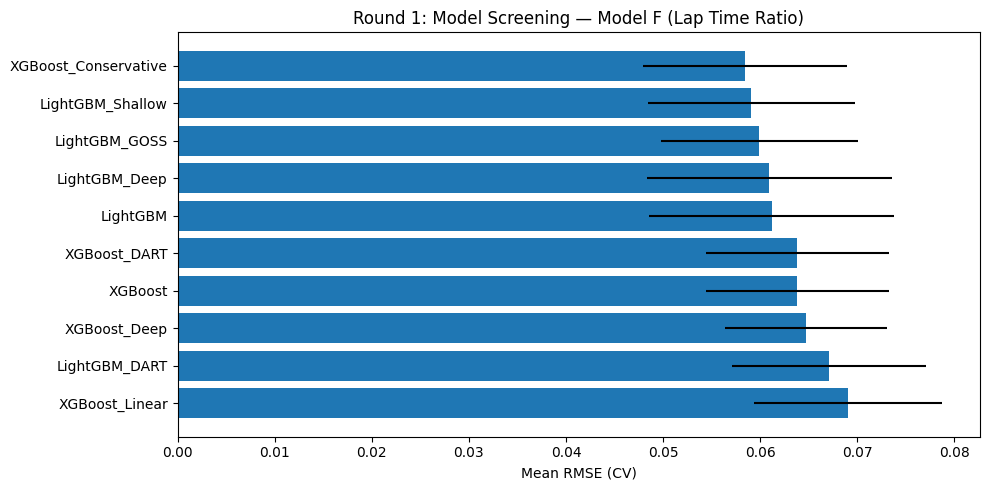

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(r1_results["model"], r1_results["mean_rmse"], xerr=r1_results["std_rmse"])
ax.set_xlabel("Mean RMSE (CV)")
ax.set_title("Round 1: Model Screening — Model F (Lap Time Ratio)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
top7_names = r1_results["model"].head(7).tolist()
print(f"Advancing to Round 2: {top7_names}")
eliminated = r1_results["model"].iloc[7:].tolist()
print(f"Eliminated: {eliminated}")

Advancing to Round 2: ['XGBoost_Conservative', 'LightGBM_Shallow', 'LightGBM_GOSS', 'LightGBM_Deep', 'LightGBM', 'XGBoost_DART', 'XGBoost']
Eliminated: ['XGBoost_Deep', 'LightGBM_DART', 'XGBoost_Linear']


## 4. Round 2 — Optuna HP Tuning (top 7, 10 trials each)

In [12]:
r2_results = []
for name in top7_names:
    print(f"Tuning {name}...")
    best_params, best_rmse = run_optuna_round(name, X, y, splitter, groups, n_trials=10)
    r2_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
    print(f"  Best RMSE: {best_rmse:.4f}")

r2_df = pd.DataFrame(r2_results).sort_values("best_rmse").reset_index(drop=True)
r2_df[["model", "best_rmse"]]

Tuning XGBoost_Conservative...


  Best RMSE: 0.0562
Tuning LightGBM_Shallow...


  Best RMSE: 0.0575
Tuning LightGBM_GOSS...


  Best RMSE: 0.0560
Tuning LightGBM_Deep...


  Best RMSE: 0.0575
Tuning LightGBM...


  Best RMSE: 0.0575
Tuning XGBoost_DART...


  Best RMSE: 0.0611
Tuning XGBoost...


  Best RMSE: 0.0562


,model,best_rmse
0,LightGBM_GOSS,0.055965
1,XGBoost_Conservative,0.056208
2,XGBoost,0.056208
3,LightGBM_Shallow,0.057478
4,LightGBM_Deep,0.057478
5,LightGBM,0.057490
6,XGBoost_DART,0.061148


In [13]:
top5_names = r2_df["model"].head(5).tolist()
r2_best_params = {row["model"]: row["best_params"] for _, row in r2_df.iterrows()}
print(f"Advancing to Round 3: {top5_names}")

Advancing to Round 3: ['LightGBM_GOSS', 'XGBoost_Conservative', 'XGBoost', 'LightGBM_Shallow', 'LightGBM_Deep']


## 5. Round 3 — Final HP Tuning (top 5, 15 trials each)

In [14]:
r3_results = []
for name in top5_names:
    print(f"Fine-tuning {name}...")
    best_params, best_rmse = run_optuna_round(name, X, y, splitter, groups, n_trials=15)
    r3_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
    print(f"  Best RMSE: {best_rmse:.4f}")

r3_df = pd.DataFrame(r3_results).sort_values("best_rmse").reset_index(drop=True)
r3_best_params = {row["model"]: row["best_params"] for _, row in r3_df.iterrows()}
r3_df[["model", "best_rmse"]]

Fine-tuning LightGBM_GOSS...


  Best RMSE: 0.0559
Fine-tuning XGBoost_Conservative...


  Best RMSE: 0.0562
Fine-tuning XGBoost...


  Best RMSE: 0.0562
Fine-tuning LightGBM_Shallow...


  Best RMSE: 0.0575
Fine-tuning LightGBM_Deep...


  Best RMSE: 0.0575


,model,best_rmse
0,LightGBM_GOSS,0.055926
1,XGBoost_Conservative,0.056208
2,XGBoost,0.056208
3,LightGBM_Deep,0.057482
4,LightGBM_Shallow,0.057483


## 6. Test Set Evaluation (Per-Lap)

In [15]:
train_idx, test_idx = splitter.get_test_split(groups)
X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]
id_train, id_test = df[ID_COLS].iloc[train_idx], df[ID_COLS].iloc[test_idx]

print(f"Train: {X_train_full.shape}, Test: {X_test.shape}")
print(f"Test season(s): {sorted(df['season'].iloc[test_idx].unique())}")

Train: (73819, 25), Test: (4787, 25)
Test season(s): [np.int64(2024)]


In [16]:
final_results = []
for name in top5_names:
    if name in DL_SKIP_OPTUNA:
        model_cls = MODEL_CLASSES[name]
        model = model_cls(input_dim=len(FEATURE_COLS))
    else:
        params = reconstruct_params(name, r3_best_params[name])
        model_cls = MODEL_CLASSES[name]
        model = model_cls(**params)
    model.fit(X_train_full, y_train_full)

    train_preds = model.predict(X_train_full)
    train_rmse = np.sqrt(mean_squared_error(y_train_full, train_preds))
    train_mae = mean_absolute_error(y_train_full, train_preds)

    test_preds = model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_mae = mean_absolute_error(y_test, test_preds)

    val_rmse = r3_df.loc[r3_df["model"] == name, "best_rmse"].values[0]

    final_results.append({
        "model": name,
        "train_rmse": train_rmse, "train_mae": train_mae,
        "val_rmse": val_rmse,
        "test_rmse": test_rmse, "test_mae": test_mae,
        "overfit_gap": test_rmse - val_rmse,
    })

    print(f"{name}: train_rmse={train_rmse:.4f}, val_rmse={val_rmse:.4f}, "
          f"test_rmse={test_rmse:.4f}, gap={test_rmse - val_rmse:.4f}")

final_df = pd.DataFrame(final_results).sort_values("test_rmse").reset_index(drop=True)
final_df

LightGBM_GOSS: train_rmse=0.0412, val_rmse=0.0559, test_rmse=0.0212, gap=-0.0348


XGBoost_Conservative: train_rmse=0.0414, val_rmse=0.0562, test_rmse=0.0213, gap=-0.0349


XGBoost: train_rmse=0.0414, val_rmse=0.0562, test_rmse=0.0213, gap=-0.0349


LightGBM_Shallow: train_rmse=0.0413, val_rmse=0.0575, test_rmse=0.0211, gap=-0.0364


LightGBM_Deep: train_rmse=0.0413, val_rmse=0.0575, test_rmse=0.0211, gap=-0.0364


,model,train_rmse,train_mae,val_rmse,test_rmse,test_mae,overfit_gap
0,LightGBM_Shallow,0.041331,0.018745,0.057483,0.021068,0.012023,-0.036415
1,LightGBM_Deep,0.041331,0.018745,0.057482,0.021068,0.012023,-0.036415
2,LightGBM_GOSS,0.041163,0.018699,0.055926,0.021161,0.012196,-0.034765
3,XGBoost_Conservative,0.041427,0.018944,0.056208,0.021312,0.012349,-0.034896
4,XGBoost,0.041427,0.018944,0.056208,0.021312,0.012349,-0.034896


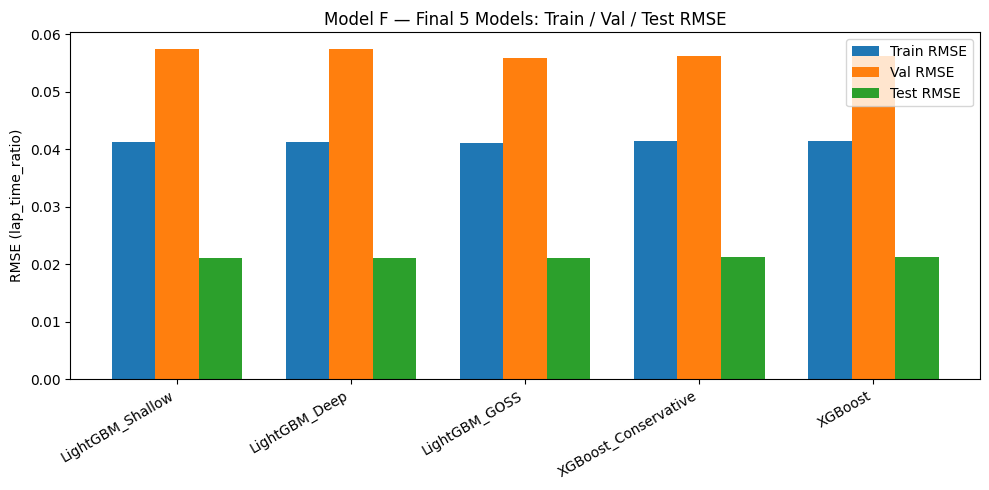

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final_df))
w = 0.25
ax.bar(x - w, final_df["train_rmse"], w, label="Train RMSE")
ax.bar(x, final_df["val_rmse"], w, label="Val RMSE")
ax.bar(x + w, final_df["test_rmse"], w, label="Test RMSE")
ax.set_xticks(x)
ax.set_xticklabels(final_df["model"], rotation=30, ha="right")
ax.set_ylabel("RMSE (lap_time_ratio)")
ax.set_title("Model F — Final 5 Models: Train / Val / Test RMSE")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Full Simulation Evaluation (2024 Test Races)

Run autoregressive simulation on test season races and compare
predicted final positions to actual finishing positions.

In [18]:
from scipy.stats import spearmanr
from f1_predictor.simulation.engine import RaceSimulator
from f1_predictor.simulation.defaults import build_circuit_defaults

circuit_defaults = build_circuit_defaults(laps)

# Use best per-lap model for simulation
best_model_name = final_df.iloc[0]["model"]
if best_model_name in DL_SKIP_OPTUNA:
    best_model = MODEL_CLASSES[best_model_name](input_dim=len(FEATURE_COLS))
else:
    best_params = reconstruct_params(best_model_name, r3_best_params[best_model_name])
    best_model = MODEL_CLASSES[best_model_name](**best_params)
best_model.fit(X_train_full, y_train_full)

simulator = RaceSimulator(best_model, circuit_defaults)
print(f"Simulator ready with {best_model_name}")
print(f"Circuits available: {len(circuit_defaults)}")

Simulator ready with LightGBM_Shallow
Circuits available: 36


In [19]:
# Get 2024 test races with qualifying data
test_races = races[races["season"] == 2024].copy()
test_race_list = test_races.groupby(["season", "round", "event_name"]).first().reset_index()

sim_results = []
for _, race_row in test_race_list.iterrows():
    event = race_row["event_name"]
    from f1_predictor.features.race_features import LOCATION_ALIASES
    event_norm = LOCATION_ALIASES.get(event, event)

    if event_norm not in circuit_defaults:
        print(f"  Skipping {event} (no circuit data)")
        continue

    # Get drivers for this race
    race_drivers = test_races[
        (test_races["season"] == race_row["season"])
        & (test_races["round"] == race_row["round"])
    ].copy()

    drivers_input = []
    actual_positions = {}
    for _, drv in race_drivers.iterrows():
        q1 = drv.get("q1_time_sec")
        q2 = drv.get("q2_time_sec")
        q3 = drv.get("q3_time_sec")
        q_times = [t for t in [q1, q2, q3] if pd.notna(t)]
        if not q_times or pd.isna(drv.get("grid_position")):
            continue

        drivers_input.append({
            "driver": drv["driver_abbrev"],
            "grid_position": int(drv["grid_position"]),
            "q1": q1 if pd.notna(q1) else None,
            "q2": q2 if pd.notna(q2) else None,
            "q3": q3 if pd.notna(q3) else None,
            "initial_tyre": "MEDIUM",
        })
        if pd.notna(drv.get("finish_position")):
            actual_positions[drv["driver_abbrev"]] = int(drv["finish_position"])

    if len(drivers_input) < 10:
        print(f"  Skipping {event} (only {len(drivers_input)} drivers with quali data)")
        continue

    try:
        result = simulator.simulate(event_norm, drivers_input)
        for fr in result.final_results:
            if fr["driver"] in actual_positions:
                sim_results.append({
                    "event": event,
                    "driver": fr["driver"],
                    "predicted_pos": fr["position"],
                    "actual_pos": actual_positions[fr["driver"]],
                })
        print(f"  {event}: simulated {len(drivers_input)} drivers")
    except Exception as e:
        print(f"  {event}: simulation failed — {e}")

sim_df = pd.DataFrame(sim_results)
print(f"\nTotal driver-race predictions: {len(sim_df)}")

  Bahrain Grand Prix: simulated 20 drivers
  Skipping Saudi Arabian Grand Prix (only 0 drivers with quali data)
  Skipping Australian Grand Prix (only 0 drivers with quali data)
  Skipping Japanese Grand Prix (only 0 drivers with quali data)
  Skipping Chinese Grand Prix (only 0 drivers with quali data)
  Skipping Miami Grand Prix (only 0 drivers with quali data)


  Emilia Romagna Grand Prix: simulated 19 drivers
  Skipping Monaco Grand Prix (only 0 drivers with quali data)
  Skipping Canadian Grand Prix (only 0 drivers with quali data)
  Skipping Spanish Grand Prix (only 0 drivers with quali data)
  Skipping Austrian Grand Prix (only 0 drivers with quali data)
  Skipping British Grand Prix (only 0 drivers with quali data)


  Hungarian Grand Prix: simulated 20 drivers
  Skipping Belgian Grand Prix (only 0 drivers with quali data)
  Skipping Dutch Grand Prix (only 0 drivers with quali data)
  Skipping Italian Grand Prix (only 0 drivers with quali data)
  Skipping Azerbaijan Grand Prix (only 0 drivers with quali data)
  Skipping Singapore Grand Prix (only 0 drivers with quali data)
  Skipping United States Grand Prix (only 0 drivers with quali data)


  Mexico City Grand Prix: simulated 20 drivers
  Skipping São Paulo Grand Prix (only 0 drivers with quali data)
  Skipping Las Vegas Grand Prix (only 0 drivers with quali data)
  Skipping Qatar Grand Prix (only 0 drivers with quali data)
  Skipping Abu Dhabi Grand Prix (only 0 drivers with quali data)

Total driver-race predictions: 79


In [20]:
# Compute simulation-level metrics
from sklearn.metrics import r2_score

if len(sim_df) > 0:
    sim_rmse = np.sqrt(mean_squared_error(sim_df["actual_pos"], sim_df["predicted_pos"]))
    sim_mae = mean_absolute_error(sim_df["actual_pos"], sim_df["predicted_pos"])
    sim_r2 = r2_score(sim_df["actual_pos"], sim_df["predicted_pos"])
    w1 = np.mean(np.abs(sim_df["actual_pos"] - sim_df["predicted_pos"]) <= 1) * 100
    w3 = np.mean(np.abs(sim_df["actual_pos"] - sim_df["predicted_pos"]) <= 3) * 100

    # Per-race Spearman
    spear_vals = []
    for event, grp in sim_df.groupby("event"):
        if len(grp) >= 3 and grp["actual_pos"].std() > 0 and grp["predicted_pos"].std() > 0:
            rho, _ = spearmanr(grp["actual_pos"], grp["predicted_pos"])
            spear_vals.append(rho)
    spearman = np.mean(spear_vals) if spear_vals else float("nan")

    print("=" * 60)
    print("MODEL F SIMULATION RESULTS (2024 Test Season)")
    print("=" * 60)
    print(f"  RMSE:        {sim_rmse:.4f}")
    print(f"  MAE:         {sim_mae:.4f}")
    print(f"  R2:          {sim_r2:.4f}")
    print(f"  Within-1:    {w1:.1f}%")
    print(f"  Within-3:    {w3:.1f}%")
    print(f"  Spearman:    {spearman:.4f}")
    print(f"  Races:       {sim_df['event'].nunique()}")
else:
    print("No simulation results to evaluate.")

MODEL F SIMULATION RESULTS (2024 Test Season)
  RMSE:        6.1900
  MAE:         5.0000
  R2:          -0.1566
  Within-1:    17.7%
  Within-3:    43.0%
  Spearman:    0.4175
  Races:       4


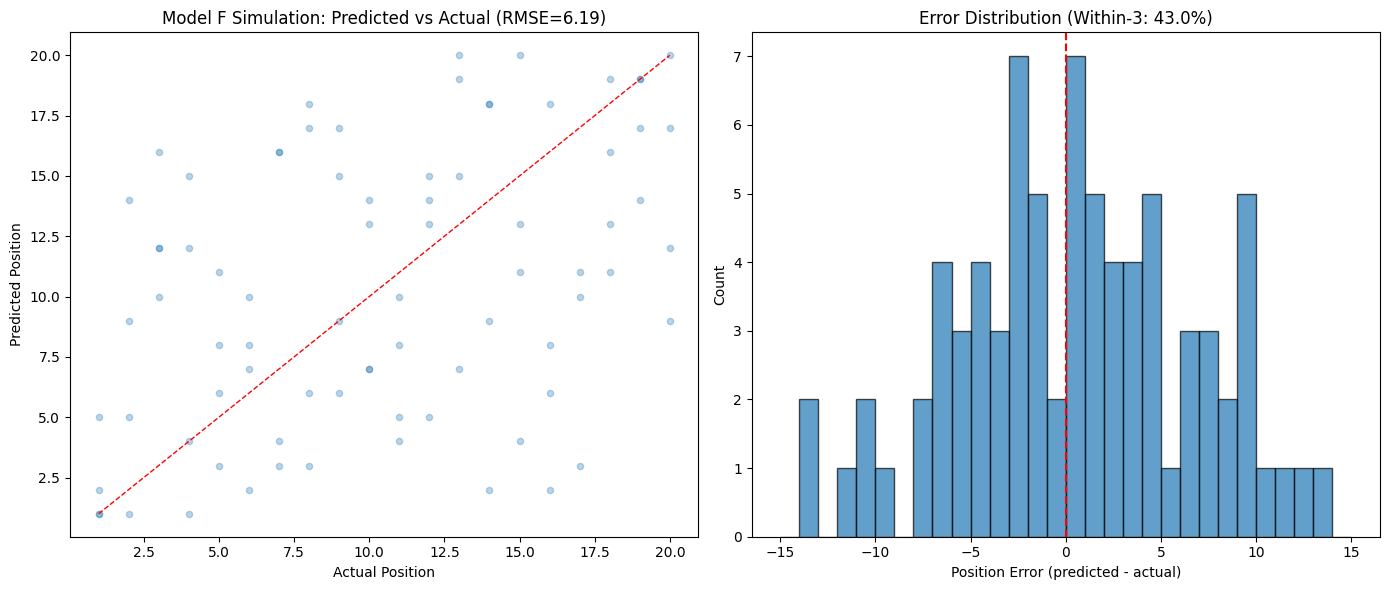

In [21]:
# Scatter plot: predicted vs actual positions
if len(sim_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(sim_df["actual_pos"], sim_df["predicted_pos"], alpha=0.3, s=20)
    ax.plot([1, 20], [1, 20], "r--", lw=1)
    ax.set_xlabel("Actual Position")
    ax.set_ylabel("Predicted Position")
    ax.set_title(f"Model F Simulation: Predicted vs Actual (RMSE={sim_rmse:.2f})")

    ax = axes[1]
    errors = sim_df["predicted_pos"] - sim_df["actual_pos"]
    ax.hist(errors, bins=range(-15, 16), edgecolor="black", alpha=0.7)
    ax.axvline(0, color="red", linestyle="--")
    ax.set_xlabel("Position Error (predicted - actual)")
    ax.set_ylabel("Count")
    ax.set_title(f"Error Distribution (Within-3: {w3:.1f}%)")

    plt.tight_layout()
    plt.show()

## 8. Save Artifacts

In [22]:
for name in top5_names:
    if name in DL_SKIP_OPTUNA:
        model_cls = MODEL_CLASSES[name]
        model = model_cls(input_dim=len(FEATURE_COLS))
    else:
        params = reconstruct_params(name, r3_best_params[name])
        model_cls = MODEL_CLASSES[name]
        model = model_cls(**params)
    model.fit(X_train_full, y_train_full)

    save_predictions(model, X_train_full, y_train_full, id_train, "F", name, "Training")
    save_predictions(model, X_test, y_test, id_test, "F", name, "Test")

    # OOF validation predictions
    oof_preds = np.full(len(X), np.nan)
    for tr_idx, va_idx in splitter.split(groups):
        import sklearn.base
        fold_model = sklearn.base.clone(model)
        fold_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof_preds[va_idx] = fold_model.predict(X.iloc[va_idx])

    val_mask = ~np.isnan(oof_preds)
    val_out = df[ID_COLS].loc[val_mask].copy()
    val_out["y_true"] = y.loc[val_mask].values
    val_out["y_pred"] = oof_preds[val_mask]
    fname = f"model_F_{name}_Validation.parquet"
    uri = save_training_parquet(val_out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")

    save_model_pkl(model, "F", name)

print("\nDone! All Model F artifacts saved.")

  Saved model_F_LightGBM_GOSS_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_F_LightGBM_GOSS_Training.parquet


  Saved model_F_LightGBM_GOSS_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_F_LightGBM_GOSS_Test.parquet


  Saved model_F_LightGBM_GOSS_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_F_LightGBM_GOSS_Validation.parquet


  Saved Model_F_LightGBM_GOSS.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_F_LightGBM_GOSS.pkl


  Saved model_F_XGBoost_Conservative_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_F_XGBoost_Conservative_Training.parquet


...

  Saved Model_F_LightGBM_Shallow.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_F_LightGBM_Shallow.pkl


  Saved model_F_LightGBM_Deep_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_F_LightGBM_Deep_Training.parquet


  Saved model_F_LightGBM_Deep_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_F_LightGBM_Deep_Test.parquet


  Saved model_F_LightGBM_Deep_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_F_LightGBM_Deep_Validation.parquet


  Saved Model_F_LightGBM_Deep.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_F_LightGBM_Deep.pkl

Done! All Model F artifacts saved.


## Summary

In [23]:
print("=" * 60)
print("MODEL F (LAP TIME SIMULATION) TRAINING COMPLETE")
print("=" * 60)
print(f"\nPer-lap evaluation (top 5, sorted by test RMSE):")
for _, row in final_df.iterrows():
    print(f"  {row['model']:20s}  test_rmse={row['test_rmse']:.6f}  "
          f"gap={row['overfit_gap']:.6f}")
if len(sim_df) > 0:
    print(f"\nFull simulation (2024 test season):")
    print(f"  Position RMSE: {sim_rmse:.4f}")
    print(f"  Spearman:      {spearman:.4f}")
    print(f"  Within-3:      {w3:.1f}%")
print(f"\nArtifacts saved to:")
print(f"  Predictions: {TRAINING_DIR}")
print(f"  Models: {MODEL_DIR}")
print(f"  Features: data/processed/simulation/")

MODEL F (LAP TIME SIMULATION) TRAINING COMPLETE

Per-lap evaluation (top 5, sorted by test RMSE):
  LightGBM_Shallow      test_rmse=0.021068  gap=-0.036415
  LightGBM_Deep         test_rmse=0.021068  gap=-0.036415
  LightGBM_GOSS         test_rmse=0.021161  gap=-0.034765
  XGBoost_Conservative  test_rmse=0.021312  gap=-0.034896
  XGBoost               test_rmse=0.021312  gap=-0.034896

Full simulation (2024 test season):
  Position RMSE: 6.1900
  Spearman:      0.4175
  Within-3:      43.0%

Artifacts saved to:
  Predictions: data/training
  Models: data/raw/model
  Features: data/processed/simulation/
